# Goodness of fit

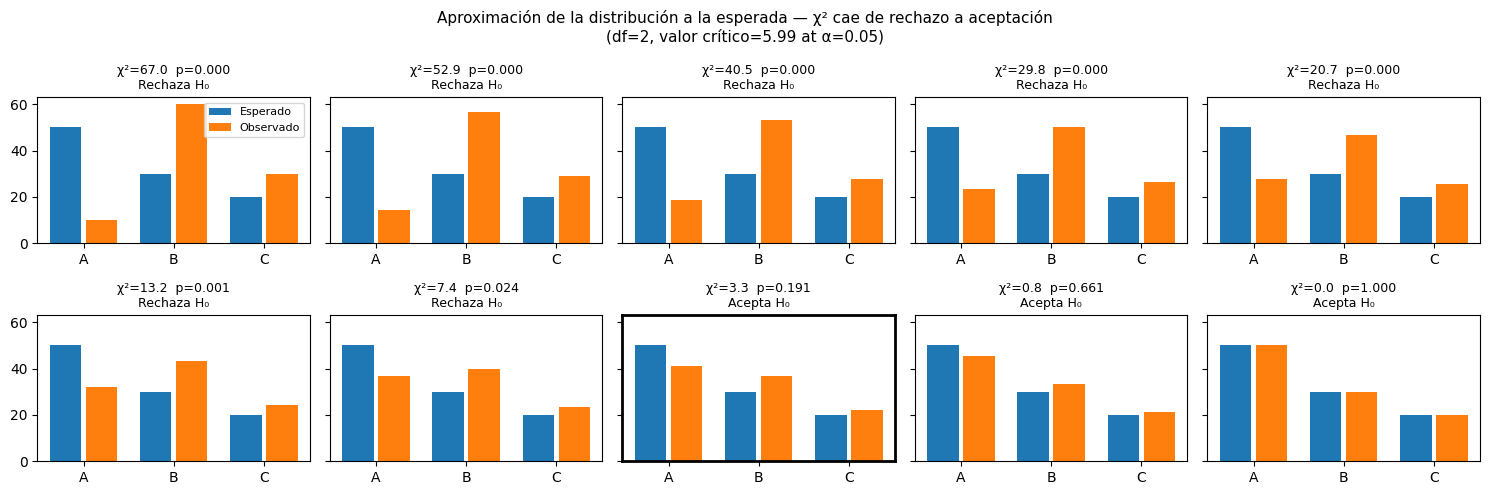

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

expected = np.array([50, 30, 20])   
start    = np.array([10, 60, 30])  

bins      = np.array(['A', 'B', 'C'])
x         = np.arange(len(expected))
df        = len(expected) - 1       
critical  = chi2.ppf(0.95, df=df)    

fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharey=True)
axes = axes.flatten()

for i, t in enumerate(np.linspace(0, 1, 10)):
    observed  = (1 - t) * start + t * expected
    chi2_stat = float(np.sum((observed - expected)**2 / expected))
    p_val     = 1 - chi2.cdf(chi2_stat, df=df)
    rejected  = chi2_stat > critical

    ax = axes[i]
    ax.bar(x - 0.2, expected, width=0.35,   label='Esperado')
    ax.bar(x + 0.2, observed, width=0.35, label='Observado')
    ax.set_xticks(x)
    ax.set_xticklabels(bins)

    status = "Rechaza H₀" if rejected else "Acepta H₀"
    ax.set_title(f'χ²={chi2_stat:.1f}  p={p_val:.3f}\n{status}', fontsize=9)

    # mark the transition step
    if not rejected and i > 0:
        prev_t = np.linspace(0, 1, 10)[i - 1]
        prev_obs  = (1 - prev_t) * start + prev_t * expected
        prev_chi2 = float(np.sum((prev_obs - expected)**2 / expected))
        if prev_chi2 > critical:
            ax.spines['bottom'].set_linewidth(2)
            ax.spines['top'].set_linewidth(2)
            ax.spines['left'].set_linewidth(2)
            ax.spines['right'].set_linewidth(2)

    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle(
    f'Aproximación de la distribución a la esperada — χ² cae de rechazo a aceptación\n'
    f'(df={df}, valor crítico={critical:.2f} at α=0.05)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('chi2_convergence.png', dpi=150, bbox_inches='tight')

# Ejemplo de la clase

In [25]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

observed = np.array([60, 10, 30, 30, 10, 60], dtype=float)
expected = np.array([35, 35, 30, 30, 35, 35], dtype=float)
labels   = ["Básico\nNav", "Básico\nStream", "Intermedio\nNav",
            "Intermedio\nStream", "Premium\nNav", "Premium\nStream"]

chi2_stat = np.sum((observed - expected)**2 / expected)
p_val     = 1 - chi2.cdf(chi2_stat, df=2)

df = pd.DataFrame({
    'Categoría': labels,
    'Observado': observed,
    'Esperado': expected
})
df

,Categoría,Observado,Esperado
0,Básico\nNav,60.0,35.0
1,Básico\nStream,10.0,35.0
2,Intermedio\nNav,30.0,30.0
3,Intermedio\nStream,30.0,30.0
4,Premium\nNav,10.0,35.0
5,Premium\nStream,60.0,35.0


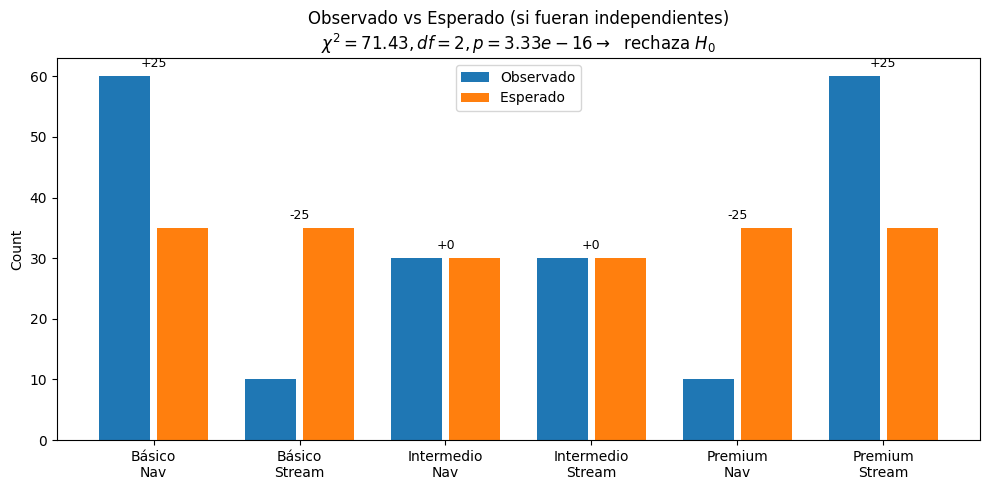

In [31]:
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 0.2, observed, width=0.35,   label='Observado')
ax.bar(x + 0.2, expected, width=0.35,  label='Esperado ')

for i in range(len(x)):
    diff = observed[i] - expected[i]
    sign = '+' if diff >= 0 else ''
    ax.text(x[i], max(observed[i], expected[i]) + 1.5,
            f'{sign}{diff:.0f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Count')
ax.set_title(f'Observado vs Esperado (si fueran independientes)\n'
             f'$\\chi^2 = {chi2_stat:.2f},  df = 2,  p = {p_val:.2e}  \\rightarrow$  rechaza $H_0$')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()

# Para un dataset sintético

In [ ]:
from scipy.stats import chi2_contingency

np.random.seed(42)
n = 500

target = np.random.choice([0, 1], size=n, p=[0.5, 0.5])

A = np.where(target == 0,
    np.random.choice(['low', 'med', 'high'], n, p=[0.7, 0.2, 0.1]),
    np.random.choice(['low', 'med', 'high'], n, p=[0.1, 0.2, 0.7]))

A_map = {'low': 0, 'med': 1, 'high': 2}
B_base = np.array([A_map[a] for a in A])
B = np.array(['X', 'Y', 'Z'])[np.clip(B_base + np.random.choice([-1,0,0,0,1], n), 0, 2)]

C = np.random.choice(['cat', 'dog', 'bird'], size=n)

D = np.where(target == 0,
    np.random.choice(['yes', 'no'], n, p=[0.65, 0.35]),
    np.random.choice(['yes', 'no'], n, p=[0.35, 0.65]))

df = pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D, 'target': target.astype(str)})
cols = ['A', 'B', 'C', 'D', 'target']
k = len(cols)

chi2_matrix = np.zeros((k, k))
pval_matrix = np.ones((k, k))

for i in range(k):
    for j in range(k):
        if i != j:
            table = pd.crosstab(df[cols[i]], df[cols[j]])
            stat, p, dof, _ = chi2_contingency(table)
            chi2_matrix[i, j] = stat
            pval_matrix[i, j] = p

sig = (pval_matrix < 0.05).astype(float)
np.fill_diagonal(sig, 0.5)


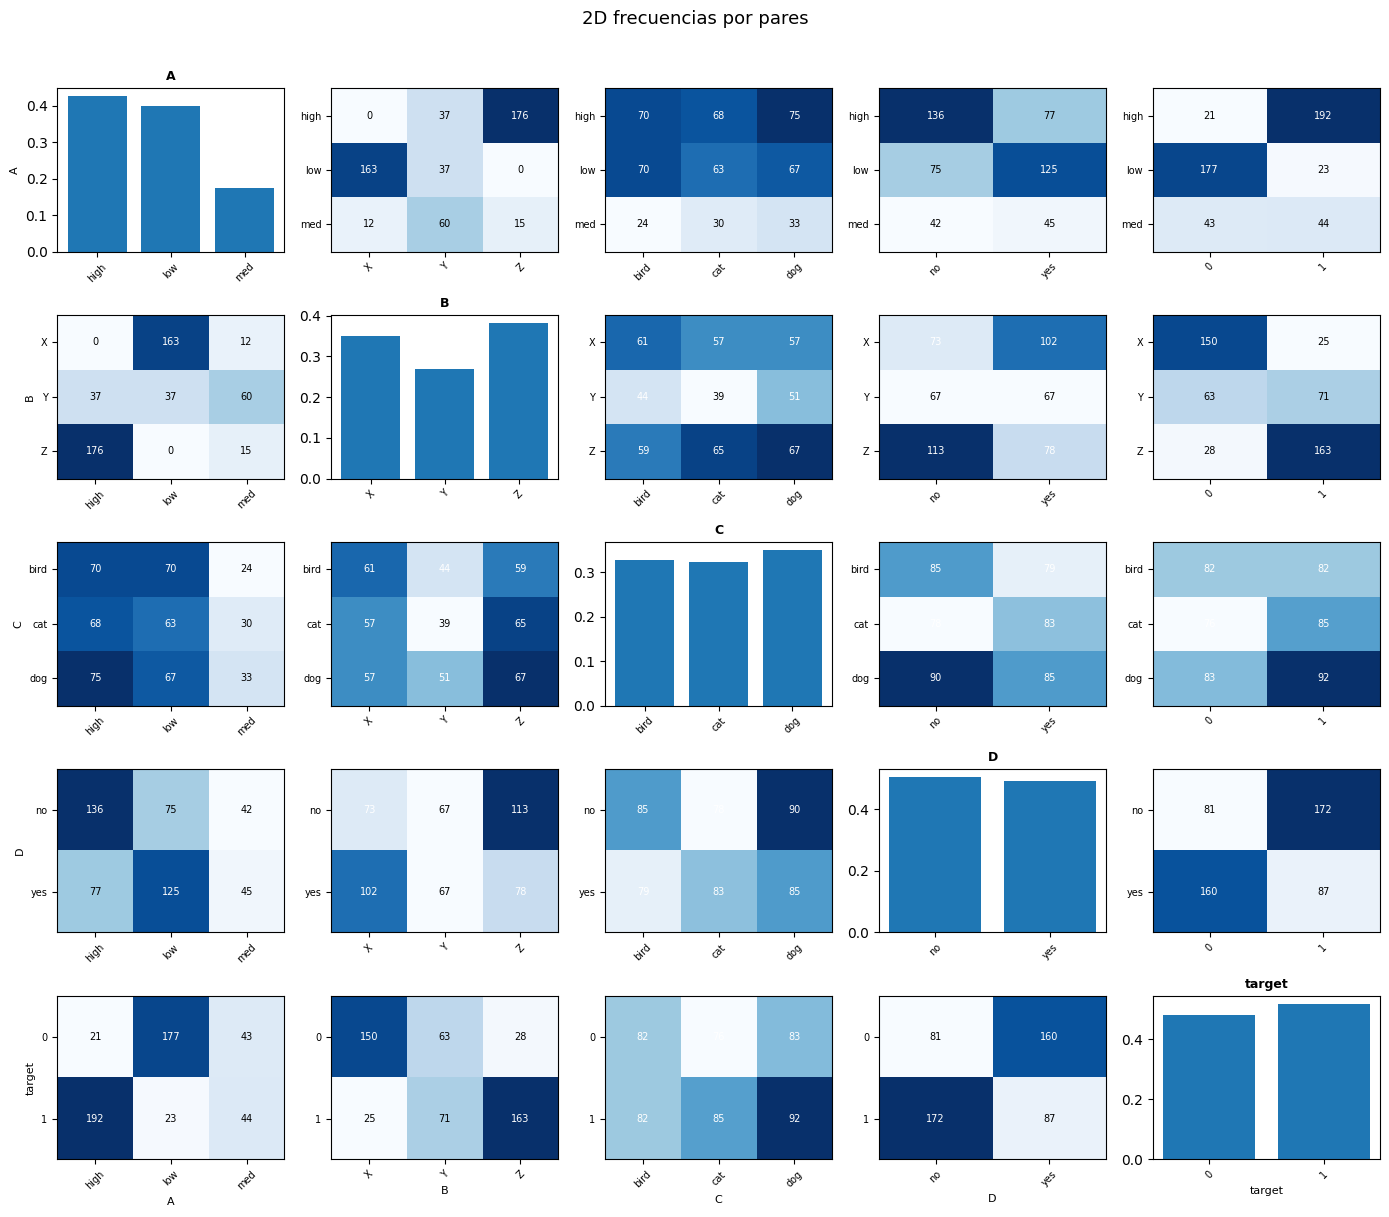

In [ ]:

k = len(cols)
fig, axes = plt.subplots(k, k, figsize=(14, 12))

for i in range(k):
    for j in range(k):
        ax = axes[i, j]

        if i == j:
            counts = df[cols[i]].value_counts().sort_index()/ len(df)
            ax.bar(range(len(counts)), counts.values, edgecolor='none')
            ax.set_xticks(range(len(counts)))
            ax.set_xticklabels(counts.index, fontsize=7, rotation=45)
            ax.set_title(cols[i], fontsize=9, fontweight='bold')
        else:
            table = pd.crosstab(df[cols[i]], df[cols[j]])
            ax.imshow(table.values, cmap='Blues', aspect='auto')
            ax.set_xticks(range(len(table.columns)))
            ax.set_yticks(range(len(table.index)))
            ax.set_xticklabels(table.columns, fontsize=7, rotation=45)
            ax.set_yticklabels(table.index, fontsize=7)
            for ii in range(table.shape[0]):
                for jj in range(table.shape[1]):
                    ax.text(jj, ii, str(table.values[ii, jj]),
                            ha='center', va='center', fontsize=7,
                            color='white' if table.values[ii, jj] > table.values.max() * 0.6 else 'black')

        if i == k - 1:
            ax.set_xlabel(cols[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(cols[i], fontsize=8)

plt.suptitle('2D frecuencias por pares', y=1.01, fontsize=13)
plt.tight_layout()

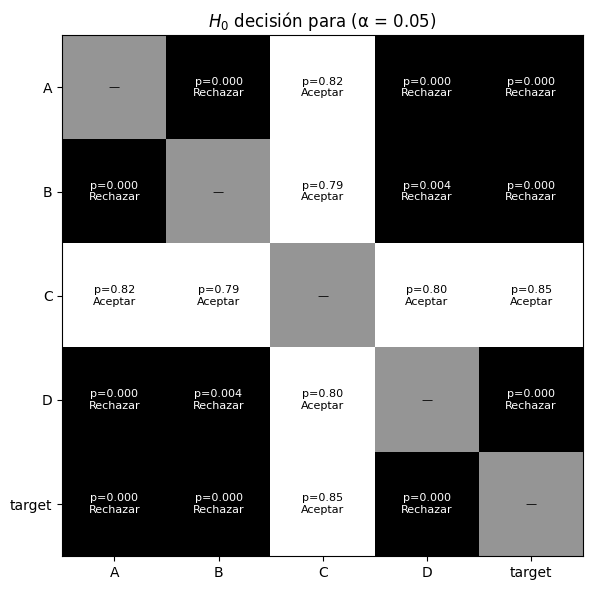

In [44]:

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(sig, cmap='Greys', vmin=0, vmax=1)

for i in range(k):
    for j in range(k):
        if i == j:
            txt = '—'
        else:
            p = pval_matrix[i, j]
            txt = f'p={p:.3f}\nRechazar' if p < 0.05 else f'p={p:.2f}\nAceptar'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                color='white' if sig[i, j] > 0.6 else 'black')

ax.set_xticks(range(k)); ax.set_yticks(range(k))
ax.set_xticklabels(cols); ax.set_yticklabels(cols)
ax.set_title('$H_0$ decisión para (α = 0.05)')
plt.tight_layout()

- A es el predictor más fuerte: contra el target
- B parece predictivo, pero es practicamente idéntico a A.
- D es moderadamente predictivo e independiente de A (relativo a B), por lo que sí añade información genuina. Se conserva.
- C no rechaza $H_0$ en ningún par. Es ruido puro.
- `SelectKBest` solo con target hubiera conservado A, B y D, hubiera fallado en detectar la redundancia de B. El análisis por pares es necesario para completar la selección.

## Procedimiento de reducción de dimensionalidad con chi-cuadrada


- Codificar o discretizar todas las variables en categorías (si no lo son ya).
- Calcular χ² entre cada feature y el target, eliminar las que no rechacen H₀ (independientes del target, p > α).
- Entre las features supervivientes, calcular χ² por pares, si dos features se rechazan entre sí (son dependientes), eliminar la de menor χ² contra el target.
- Verificar que los conteos esperados en todas las tablas de contingencia sean ≥ 5 antes de confiar en los p-valores.
- Con las features seleccionadas, reentrenar el modelo y comparar desempeño.

## Cuándo usarlo y cuándo tener cuidado

- Cuando las variables ya son categóricas de forma natural.
- **variables continuas**: la discretización en bins es arbitraria, distintos números de bins producen distintos χ² y distintas conclusiones. Preferir `mutual_info_classif` en ese caso.
- **Para muestras pequeñas**: si algún conteo esperado cae por debajo de 5, la aproximación normal colapsa y el p-valor no es confiable. Se puede usar Fisher's exact test como alternativa.
- No es bueno para detectar relaciones no lineales complejas entre features continuas


## **2.4 Fisher Score (chi-square implementation)** <a class="anchor" id="2.4"></a>

- It is the **chi-square implementation** in scikit-learn. It computes chi-squared stats between each non-negative feature and class.

- This score should be used to evaluate categorical variables in a classification task. It compares the observed distribution of the different classes of target Y among the different categories of the feature, against the expected distribution of the target classes, regardless of the feature categories. 

In [ ]:
# load libraries
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2

In [ ]:
# Load Data
# load iris data
iris = load_iris()

# create features and target
X = iris.data
y = iris.target

# convert to categorical data by converting data to integers
X = X.astype(int)

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
# Compare Chi-Squared Statistics
# select two features with highest chi-squared statistics
chi2_selector = SelectKBest(chi2, k=2)
X_kbest = chi2_selector.fit_transform(X, y)

In [ ]:
# View results
print('Original number of features:', X.shape[1])
print('Reduced number of features:', X_kbest.shape[1])

Original number of features: 4
Reduced number of features: 2


Sin embargo puede fallar si no se hace bien el orden

In [53]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

# codificar a enteros — chi2 de sklearn requiere valores no negativos
enc = OrdinalEncoder()
X = enc.fit_transform(df[['A', 'B', 'C', 'D']])
y = df['target'].astype(int)

selector = SelectKBest(chi2, k=2)
selector.fit(X, y)

results = pd.DataFrame({
    'feature':   ['A', 'B', 'C', 'D'],
    'chi2_score': selector.scores_.round(2),
    'p_value':    selector.pvalues_.round(4),
    'selected':   selector.get_support()
})
print(results.sort_values('chi2_score', ascending=False))

  feature  chi2_score  p_value  selected
1       B      130.60   0.0000      True
0       A       73.30   0.0000      True
3       D       27.19   0.0000     False
2       C        0.15   0.7033     False
